In [1]:
import sys
import os

# Получаем текущую рабочую директорию (где сохранён ноутбук)
notebook_dir = os.getcwd()

# Добавляем корень проекта (на один уровень выше текущей директории) в sys.path
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
# sys.path.append(project_root)
sys.path.append(notebook_dir)

project_root,notebook_dir

# Теперь можно импортировать модуль
# import models.ttt as ttt

# h=ttt.hello()
# h


('D:\\Works\\Jupiter notebook', 'D:\\Works\\Jupiter notebook\\Stock_market')

In [2]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Загрузка excel файла
data_csv = pd.read_csv("in_datas/eth_2025_full.csv")

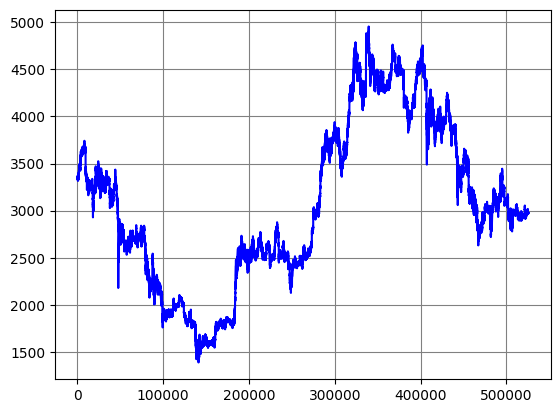

In [4]:
plt.plot(data_csv.index, data_csv['close'], color="blue", label="Цена")
plt.grid(True, color="gray")
plt.show()

In [5]:
data_in = data_csv.head(20000)
# data_out = pd.DataFrame()
data_in

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base,taker_buy_quote,ignore
0,1735689600000000,3337.78,3337.99,3335.84,3337.99,171.7281,1735689659999999,572995.650941,1190,66.7579,222751.345731,0
1,1735689660000000,3337.99,3338.86,3337.42,3338.86,69.0122,1735689719999999,230380.714834,945,31.0429,103626.095655,0
2,1735689720000000,3338.86,3342.32,3338.86,3342.32,104.9957,1735689779999999,350798.355486,1684,79.9568,267131.850080,0
3,1735689780000000,3342.32,3342.44,3338.96,3339.98,183.7958,1735689839999999,613930.038685,1321,30.7626,102757.873866,0
4,1735689840000000,3339.98,3343.02,3339.98,3340.26,177.9110,1735689899999999,594595.879953,1168,126.0131,421164.034611,0
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1736889300000000,3226.77,3227.40,3225.34,3225.77,97.1579,1736889359999999,313477.940564,871,24.9051,80346.540733,0
19996,1736889360000000,3225.78,3228.81,3224.69,3228.81,93.0747,1736889419999999,300316.126143,1142,60.9251,196591.145977,0
19997,1736889420000000,3228.80,3231.00,3227.93,3230.99,152.5667,1736889479999999,492732.803774,1366,87.3288,282025.593850,0
19998,1736889480000000,3230.99,3232.00,3230.34,3231.65,253.8656,1736889539999999,820201.642522,1050,190.5035,615469.081442,0


In [6]:
# # Основной цикл расчета
# for index, row in tqdm(data_in.iterrows(), total=len(data_in), desc="Расчет"):
#     time = row['open_time']
#     price = row['close']

#     processed_row = {
#         'time': time,
#         'price': price,
#         'PnL': '',
#         'Capital': '',
#         'Size Pool': '', #+
#         'Size Short': '',
#         'Cash Pool': '', #+
#         'Cash Short': '',
#         'Status Pool': '', #+
#         'Status Short': '',
#         'Action desc Pool': '',
#         'Action desc Short': '',
#         #---
#         'Pa': '',
#         'Pb': '',
#         'Pn': '',
#         'Pn Short': ''
#         # 'Pool_close': pool.IsClose,
#         # # 'Short_close': short.IsClose,
#         # 'Pool_Pb': pool.Pb,
#         # 'Pool_Pn': pool.Pn,
#         # 'Pool_Pa': pool.Pa,
#     }
#     data_out = pd.concat([data_out, pd.DataFrame(processed_row, index=[0])], ignore_index=True)

In [7]:
def set_async_factor(k) -> (float, float):
        if k == 0:
            k_b = k_a = 0.5
        dirCoef = round(abs(k), 2)
        resideCoef = round(1 - dirCoef, 2)
        if k < 0:
            k_b = resideCoef
            k_a = dirCoef
        if k > 0:
            k_b = dirCoef
            k_a = resideCoef
        return (k_a, k_b)

def calc_range(p_range: float, pn: float, k: float):
    k_a, k_b = set_async_factor(k)
    pb = pn + p_range * k_b
    pa = pn - p_range * k_a
    return (pa, pb)

In [8]:
# --- ИСПРАВЛЕННАЯ ФОРМУЛА ликвидности для Uniswap V3 ---
def calculate_liquidity(capital_amount, pn_price, pa_price, pb_price):
    """Правильная формула ликвидности для Uniswap V3"""
    if pn_price <= pa_price or pn_price >= pb_price:
        pn_price = (pa_price + pb_price) / 2
    
    sqrt_pn = np.sqrt(pn_price)
    sqrt_pa = np.sqrt(pa_price)
    sqrt_pb = np.sqrt(pb_price)
    
    term1 = sqrt_pn - sqrt_pa
    term2 = pn_price * (1/sqrt_pn - 1/sqrt_pb)
    if (term1 + term2) == 0:
        return 0.0
    
    l = capital_amount / (term1 + term2)
    
    # if verbose_logging and abs(calculate_pool_value(pn_price, pa_price, pb_price, l) - capital_amount) > capital_amount * 0.01:
    #     print(f"  Внимание: разница в расчетах. Capital=${capital_amount:.2f}, Pool Value at Pn=${calculate_pool_value(pn_price, pa_price, pb_price, l):.2f}")
    return l

In [9]:
# Рассчитывает стоимость пула при заданной цене ТОЛЬКО по формуле V3
def calculate_pool_value(price, pa, pb, l):
    """Рассчитывает стоимость пула при заданной цене ТОЛЬКО по формуле V3"""
    if l <= 0:
        return 0.0
    sqrt_price = np.sqrt(price)
    sqrt_pa = np.sqrt(pa)
    sqrt_pb = np.sqrt(pb)
    if price <= pa: # close on ниже Pa
        pool_eth = l * (1/sqrt_pa - 1/sqrt_pb)
        return pool_eth * price
    elif price >= pb: # close on выше Pb
        return l * (sqrt_pb - sqrt_pa)
    else: # в створе
        pool_usdc = l * (sqrt_price - sqrt_pa)
        pool_eth = l * (1/sqrt_price - 1/sqrt_pb)
        return pool_usdc + pool_eth * price

In [10]:
class Short:
    po: float
    futures: int
    capital: float
    is_open: bool = False

In [11]:
class Pool:
    p_o: float = None # Цена в точке открытия
    p_t: float = None # Текущая цена
    capital: float
    is_open: bool = False
    p_a: float # Нижняя граница
    p_b: float # Верхняя граница
    liquidity: float # Ликвидность
    # count_USDC: float
    # count_ETH: float

    def __init__(self):
        self.capital = 0.0

    def step(self, price: float):
        self.p_t = price
    
    @property
    def d_price(self):
        return self.p_t - self.p_o

    @property
    def pool_cost(self):
        """Рассчитывает стоимость пула при заданной цене ТОЛЬКО по формуле V3"""
        if self.liquidity <= 0:
            return 0.0
        sqrt_price = np.sqrt(self.p_t)
        sqrt_pa = np.sqrt(self.p_a)
        sqrt_pb = np.sqrt(self.p_b)
        if price <= pa: # close on ниже Pa
            pool_eth = self.liquidity * (1/sqrt_pa - 1/sqrt_pb)
            return pool_eth * price
        elif price >= pb: # close on выше Pb
            return self.liquidity * (sqrt_pb - sqrt_pa)
        else: # в створе
            pool_usdc = self.liquidity * (sqrt_price - sqrt_pa)
            pool_eth = self.liquidity * (1/sqrt_price - 1/sqrt_pb)
            return pool_usdc + pool_eth * price

    # def calculate_liquidity(capital_amount, pn_price, pa_price, pb_price):
    def calculate_liquidity(self, capital_amount, pn_price, pa_price, pb_price):
        """Правильная формула ликвидности для Uniswap V3"""
        if pn_price <= pa_price or pn_price >= pb_price:
            pn_price = (pa_price + pb_price) / 2
        
        sqrt_pn = np.sqrt(pn_price)
        sqrt_pa = np.sqrt(pa_price)
        sqrt_pb = np.sqrt(pb_price)
        
        term1 = sqrt_pn - sqrt_pa
        term2 = pn_price * (1/sqrt_pn - 1/sqrt_pb)
        if (term1 + term2) == 0:
            return 0.0
        
        l = capital_amount / (term1 + term2)
        
        # if verbose_logging and abs(calculate_pool_value(pn_price, pa_price, pb_price, l) - capital_amount) > capital_amount * 0.01:
        #     print(f"  Внимание: разница в расчетах. Capital=${capital_amount:.2f}, Pool Value at Pn=${calculate_pool_value(pn_price, pa_price, pb_price, l):.2f}")
        return l
    
    # def open(self, capital: float, price: float):
    def open(self, capital_amount, pn_price, pa_price, pb_price):
        if not self.is_open: 
            # Расчитать ликвидность
            self.liquidity = self.calculate_liquidity(capital_amount, price, pa_price, pb_price)
            # # self.capital = capital
            # self.count_ETH = self.capital * price
            self.p_o = price
            self.p_t = price
            self.p_a = pa_price
            self.p_b = pb_price
            self.is_open = True
            # self.capital = self.count_ETH
            return self.pool_cost
        # self.capital = capital
        return self.capital

    def close(self):
        if self.is_open:
            self.count_USDC = self.capital * price
            self.is_open = False
            self.capital = self.count_USDC
            return self.pool_cost #self.count_USDC #self.d_price * self.capital
        return self.capital

    def info(self):
        return {
            'Delta price': self.d_price,
            'Liquidity': self.liquidity,
            'Size': self.pool_cost,
            'Cache': self.capital, #self.d_price * self.capital,
            'Status': 'open' if self.is_open else 'close',
            'Desc action': ''
        }

In [12]:
class Exchange:
    price_data: pd.DataFrame
    pool: Pool
    step: int

    def __init__(self, data_in):
        self.price_data = data_in
        self._total_iterations = len(data_in)
        self.reset_step()
        _, price = self.get_step()
        self.pool = Pool()
        # self.pool_capital = self.pool.open(10000, price)
        self.pool_capital = 10000

    def reset_step(self):
        self.step = 0

    def go_step(self):
        self.step +=1
        if self.is_not_finish:
            time, price = self.get_step()
            self.pool.step(price)
        return self.step

    @property
    def is_not_finish(self):
        return self.step < self.total_iterations

    @property
    def total_iterations(self):
        return self._total_iterations

    # def set_state_pool(self, is_open: bool):
    #     if is_open:
    #         _, price = self.get_step()
    #         self.pool_capital = self.pool.open(self.pool_capital, price)
    #     else:
    #         self.pool_capital = self.pool.close()

    def open_pool(self,pa,pb):
        _, price = self.get_step()
        self.pool_capital = self.pool.open(self.pool_capital, price, pa,pb)

    def close_pool(self):
        self.pool_capital = self.pool.close()

    def get_step(self):
        row = self.price_data.iloc[self.step]
        return (row['open_time'], row['close'])

    def get_report_on_step(self):
        time, price = self.get_step()
        out_dict = {
            'step': self.step,
            'time': time,
            'price': price,
            'PnL': '',
            'Capital': '',
            'Size Pool': self.pool_capital,#self.pool.d_price, #+
            'Size Short': '',
            'Cash Pool': '', #+
            'Cash Short': '',
            'Status Pool': 'open' if self.pool.is_open else 'close', #+
            'Status Short': '',
            'Action desc Pool': '',
            'Action desc Short': '',
            #---
            # 'Pa': '',
            # 'Pb': '',
            # 'Pn': '',
            # 'Pn Short': ''
            # 'Pool_close': pool.IsClose,
            # # 'Short_close': short.IsClose,
            # 'Pool_Pb': pool.Pb,
            # 'Pool_Pn': pool.Pn,
            # 'Pool_Pa': pool.Pa,
        }
        out_dict.update(self.pool.info())
        return out_dict

In [13]:
def run_trigger(price: float, pa: float, pb: float, ex: Exchange):
    if not ex.pool.is_open:
        # pa, pb = calc_range(price, 0.3)
        # ex.set_state_pool(True)
        ex.open_pool(pa,pb)
        return
    if price <= pa or price >=pb:
        # ex.set_state_pool(False)
        ex.close_pool()
        

In [14]:
# Основной цикл расчета
ex = Exchange(data_in)
progress_bar = tqdm(total=ex.total_iterations, desc="Processing", unit=" итерация")
data_out = pd.DataFrame()
pool_range = 10
pa = pb = None
while ex.is_not_finish:
    # time.sleep(0.5)
    step = ex.step
    time, price = ex.get_step()
    # здесь поставить триггеры
    if not ex.pool.is_open or (pa == pb):
        pa, pb = calc_range(pool_range, price, 0.3)
    run_trigger(price, pa, pb, ex)
    # Отчет
    processed_row = ex.get_report_on_step()
    processed_row['Pa'] = pa
    processed_row['Pb'] = pb
    # processed_row['Pn'] = ''
    # processed_row['Pn Short'] = ''
    data_out = pd.concat([data_out, pd.DataFrame(processed_row, index=[0])], ignore_index=True)
    step_num = ex.go_step() # Перейти на следующую итерацию
    progress_bar.update(1)
progress_bar.close()
data_out

Processing: 100%|████████████████████████████████████████████████████████| 20000/20000 [00:25<00:00, 798.31 итерация/s]


,step,time,price,PnL,Capital,Size Pool,Size Short,Cash Pool,Cash Short,Status Pool,...,Action desc Pool,Action desc Short,Delta price,Liquidity,Size,Cache,Status,Desc action,Pa,Pb
0,0,1.735690e+15,3337.99,,,10000.000000,,,,open,...,,,0.00,115531.583405,10000.000000,0.0,open,,3330.99,3340.99
1,1,1.735690e+15,3338.86,,,10000.000000,,,,open,...,,,0.87,115531.583405,10000.667909,0.0,open,,3330.99,3340.99
2,2,1.735690e+15,3342.32,,,10001.346683,,,,close,...,,,4.33,115531.583405,10001.346683,0.0,close,,3330.99,3340.99
3,3,1.735690e+15,3339.98,,,10001.346683,,,,open,...,,,0.00,115581.590845,10001.346683,0.0,open,,3332.98,3342.98
4,4,1.735690e+15,3340.26,,,10001.346683,,,,open,...,,,0.28,115581.590845,10001.586269,0.0,open,,3332.98,3342.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,1.736889e+15,3225.77,,,2389.712670,,,,open,...,,,-5.23,27162.515693,2387.541027,0.0,open,,3224.00,3234.00
19996,19996,1.736889e+15,3228.81,,,2389.712670,,,,open,...,,,-2.19,27162.515693,2389.049766,0.0,open,,3224.00,3234.00
19997,19997,1.736889e+15,3230.99,,,2389.712670,,,,open,...,,,-0.01,27162.515693,2389.710449,0.0,open,,3224.00,3234.00
19998,19998,1.736889e+15,3231.65,,,2389.712670,,,,open,...,,,0.65,27162.515693,2389.841151,0.0,open,,3224.00,3234.00


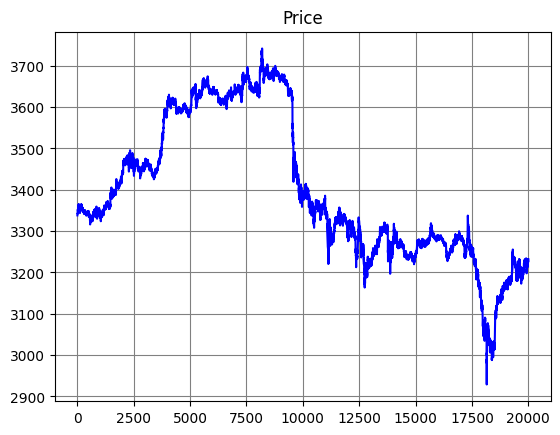

In [15]:
plt.title("Price")
plt.plot(data_out['step'], data_out['price'], color="blue", label="Цена")
# plt.plot(data_out['step'], data_out['Size Pool'], color="orange", label="Цена")
plt.grid(True, color="gray")
plt.show()

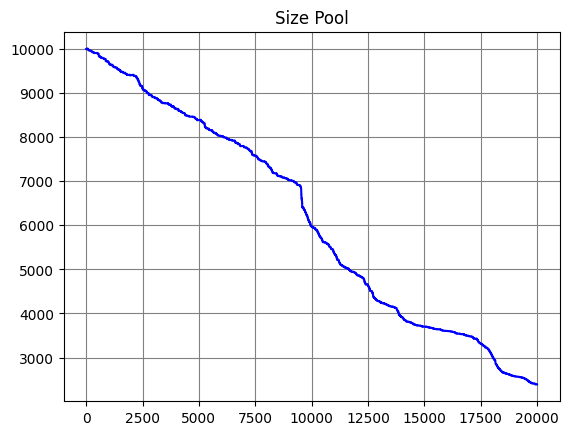

In [16]:
plt.title("Size Pool")
plt.plot(data_out['step'], data_out['Size Pool'], color="blue", label="Цена")
plt.grid(True, color="gray")
plt.show()

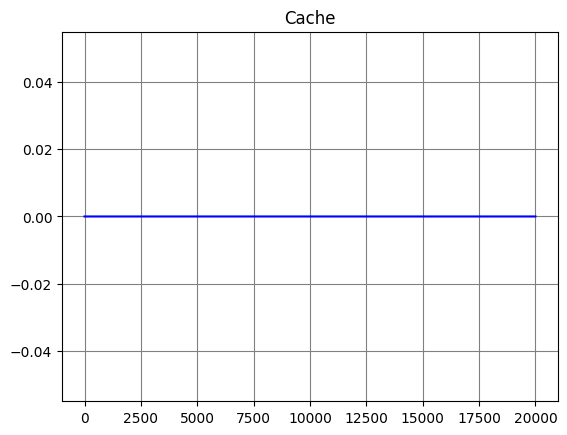

In [17]:
plt.title("Cache")
plt.plot(data_out['step'], data_out['Cache'], color="blue", label="Цена")
plt.grid(True, color="gray")
plt.show()

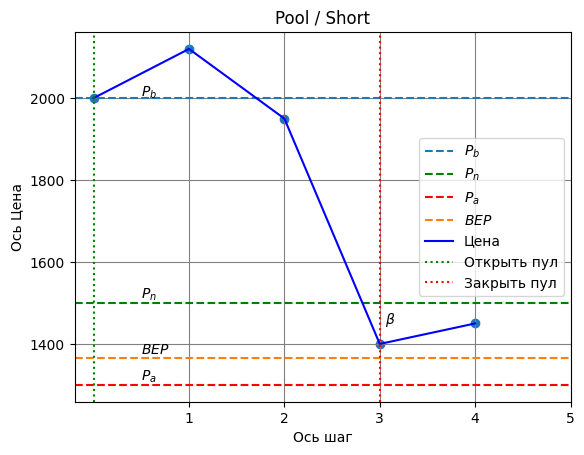

In [18]:
# import matplotlib.pyplot as plt
pb = 2000
pn = 1500
pa = 1300
bep = 1365
prices = np.array([2000, 2120, 1950, 1400, 1450])

step_count = 5  # len(prices)
steps = np.arange(step_count, dtype=np.int16)

plt.axhline(y=pb, linestyle="--", label="$P_b$")
plt.axhline(y=pn, linestyle="--", color="g", label="$P_n$")
plt.axhline(y=pa, linestyle="--", color="red", label="$P_a$")
plt.axhline(y=bep, linestyle="--", color="tab:orange", label="$BEP$")

plt.scatter(steps, prices)
plt.plot(steps, prices, color="blue", label="Цена")

plt.axvline(x=0, color="g", linestyle=":", label="Открыть пул")
plt.axvline(x=3, color="r", linestyle=":", label="Закрыть пул")

plt.annotate("$P_{b}$", (0.5, pb+5))
plt.annotate("$P_{a}$", (0.5, pa+10))
plt.annotate("$P_{n}$", (0.5, pn+10))
plt.annotate("$BEP$", (0.5, bep+10))
plt.annotate("$P_{loss}$", (1, prices[1] + 50))
plt.annotate("$\\beta$", (3 + 0.05, prices[3] + 50))

plt.xticks(steps + 1)

plt.title("Pool / Short")
plt.xlabel("Ось шаг")
plt.ylabel("Ось Цена")
# plt.grid(False)
plt.grid(True, color="gray")
plt.legend(loc="best")
plt.show()

In [19]:
# pool = Pool(100)

# price = 123

# pool.step(price)
# pool.open(price)
# if pool.is_open:
#     print('open')
# else:
#     print('close')
# pool.close()
# type(pool.info())
# df = pd.DataFrame([pool.info()])
# df

# Биржа

источник цены

## Основные функции

- порупка
- продажа

имеет `акаунт`

## Акаунт
- счёт (капитал) = счет пул + счет шорт
- `пул`
- `шорт`
- размер коммисии ( 0.25% комиссия за сделку)
- APR ( 60% годовая доходность (для пула))

## Пул

- $P_o$ (точка открытия)
- $P_c$ (точка закрытия)
- $Size$ (размер, объём) = $P_c-P_o$
- капитал

Действия:

- открыть
- закрыть
- выдать отчет

Вычесления:
- при открытии вычесляет:  
    $P_o=P_t$
  
- при закрытии:    
    $Капитал = Капитал + Size$    
    $Size = 0$

## Шорт

- $P_o$ (точка открытия)
- $P_c$ (точка закрытия)
- $Size$ (размер, объём) = $P_o-P_c$
- капитал

# Отчет

- Время(шаг)
- Цена
- Капитал общий
- Величина APR
- Размер пул
- Размер шорт
- состояние пул
- состояние шорт
- описание состояния пул
- описание состояния шорт
- $P_b$
- $P_n$
- $P_a$
- $BEP$
- $PnL$

```mermaid
sequenceDiagram
autonumber
    loop Ежеминутная Цена
        Exchange->>Bot : Цена
        alt Pool закрыт
            create participant Pool
            Bot->>Pool : Open
            Pool-->>Bot : Report
        else норма
            Pool-->>Bot : Report
        else триггер сработал
            Bot->>Pool : Close
            destroy Pool
            Pool-->>Bot : Report
        end
    end
```

```mermaid
sequenceDiagram
autonumber
participant Bot
participant Exchange
%% participant Pool
    loop Ежеминутная Цена
        Exchange->>Bot : Цена
        alt Pool закрыт
            Bot ->> Exchange: OpenPool()
            create participant Pool
            Exchange ->> Pool : Open
            Pool-->>Exchange : Report
            Exchange-->>Bot : Report
        else норма
            Pool-->>Exchange : Report
            Exchange-->>Bot : Report
        else триггер сработал
            Bot->>Exchange : Close
            destroy Pool
            Pool-->>Exchange : Report
            Exchange-->>Bot: Report
        end
    end
```